## 1. Dependencies

In [1]:
!pip install -q rdflib langchain-ollama langchain-community langchain-text-splitters chromadb pypdf langgraph


## 2. Loading the rdf data as an input knowledge graph

In [2]:
from pathlib import Path
from rdflib import Graph

_HERE = Path(__file__).parent if "__file__" in dir() else Path.cwd()
g = Graph()
g.parse(str(Path.home() / "Desktop" / "emdat_climate_events26.ttl"), format="ttl")
print(f"Loaded {len(g)} triples")


Loaded 69124 triples


## 3. Defining the LLMs for each different task

In [3]:
from langchain_ollama import ChatOllama

# Main model — KG exploration, SPARQL querying, synthesis, feedback
llm = ChatOllama(model="gpt-oss:120b-cloud", temperature=1, num_ctx=4096)

# Router — lightweight classifier, no tools
llm_router = ChatOllama(model="gpt-oss:120b-cloud", temperature=0, num_ctx=4096)

# RAG model — semantic search distillation
llm_rag_model = ChatOllama(model="gpt-oss:120b-cloud", temperature=0, num_ctx=4096)


## 4. RAG — Loading the knowledge sources as pdfs and websites

In [4]:
import os, functools
from pathlib import Path
from langchain_community.document_loaders import PyPDFLoader, WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_ollama import OllamaEmbeddings

# Optional local PDFs. Keep this empty if the RAG corpus should only use web pages.
PDF_PATHS = [str(Path.home() / "Desktop" / "world_weather_attribution.pdf")]

# Website corpus used by the RAG component. Duplicates are removed before indexing.
WEBSITE_URLS = [
    'https://www.worldweatherattribution.org/a-quick-look-at-the-extreme-rainfall-in-japan/',
    'https://www.worldweatherattribution.org/analysis/cold-spells/',
    'https://www.worldweatherattribution.org/bangladesh-floods-august-2017/',
    'https://www.worldweatherattribution.org/chennai-floods-december-2015/',
    'https://www.worldweatherattribution.org/climate-change-added-4bn-to-damage-of-japans-typhoon-hagibis/',
    'https://www.worldweatherattribution.org/climate-change-exacerbated-heavy-rainfall-leading-to-large-scale-flooding-in-highly-vulnerable-communities-in-west-africa/',
    'https://www.worldweatherattribution.org/climate-change-exacerbated-rainfall-causing-devastating-flooding-in-eastern-south-africa/',
    'https://www.worldweatherattribution.org/climate-change-increased-heavy-precipitation-associated-with-impactful-storm-bettina-over-black-sea/',
    'https://www.worldweatherattribution.org/climate-change-increased-heavy-rainfall-hitting-vulnerable-communities-in-eastern-northeast-brazil/',
    'https://www.worldweatherattribution.org/climate-change-increased-rainfall-associated-with-tropical-cyclones-hitting-highly-vulnerable-communities-in-madagascar-mozambique-malawi/',
    'https://www.worldweatherattribution.org/climate-change-indian-ocean-dipole-compounding-natural-hazards-and-high-vulnerability-increased-severity-of-flooding-in-the-horn-of-africa/',
    'https://www.worldweatherattribution.org/climate-change-likely-increased-extreme-monsoon-rainfall-flooding-highly-vulnerable-communities-in-pakistan/',
    'https://www.worldweatherattribution.org/climate-change-made-devastating-early-heat-in-india-and-pakistan-30-times-more-likely/',
    'https://www.worldweatherattribution.org/climate-change-made-the-floods-in-southern-brazil-twice-as-likely/',
    'https://www.worldweatherattribution.org/climate-change-more-than-doubled-the-likelihood-of-extreme-fire-weather-conditions-in-eastern-canada/',
    'https://www.worldweatherattribution.org/climate-change-not-el-nino-main-driver-of-exceptional-drought-in-highly-vulnerable-amazon-river-basin/',
    'https://www.worldweatherattribution.org/conflict-poverty-and-water-management-issues-exposing-vulnerable-communities-in-africa-to-extreme-floods-that-are-now-common-events-because-of-climate-change/',
    'https://www.worldweatherattribution.org/deadly-mediterranean-heatwave-would-not-have-occurred-without-human-induced-climate-change/',
    'https://www.worldweatherattribution.org/despite-known-coastal-cooling-trend-risk-of-deadly-wildfires-in-central-chile-increasing-with-changing-land-management-in-a-warming-climate/',
    'https://www.worldweatherattribution.org/el-nino-key-driver-of-drought-in-highly-vulnerable-southern-african-countries/',
    'https://www.worldweatherattribution.org/ethiopia-drought-2015/',
    'https://www.worldweatherattribution.org/european-heat-june-2017/',
    'https://www.worldweatherattribution.org/european-rainstorms-may-2016/',
    'https://www.worldweatherattribution.org/extreme-heat-australia-february-2017/',
    'https://www.worldweatherattribution.org/extreme-heat-in-north-america-europe-and-china-in-july-2023-made-much-more-likely-by-climate-change/',
    'https://www.worldweatherattribution.org/extreme-heat-killing-more-than-100-people-in-mexico-hotter-and-much-more-likely-due-to-climate-change/',
    'https://www.worldweatherattribution.org/heavy-precipitation-hitting-vulnerable-communities-in-the-uae-and-oman-becoming-an-increasing-threat-as-the-climate-warms/',
    'https://www.worldweatherattribution.org/human-contribution-to-record-breaking-june-2019-heatwave-in-france/',
    'https://www.worldweatherattribution.org/human-induced-climate-change-compounded-by-socio-economic-water-stressors-increased-severity-of-drought-in-syria-iraq-and-iran/',
    'https://www.worldweatherattribution.org/human-induced-climate-change-increased-drought-severity-in-southern-horn-of-africa/',
    'https://www.worldweatherattribution.org/hurricane-florence-september-2018/',
    'https://www.worldweatherattribution.org/hurricane-harvey-august-2017/',
    'https://www.worldweatherattribution.org/increasing-april-may-rainfall-el-nino-and-high-vulnerability-behind-deadly-flooding-in-afghanistan-pakistan-and-iran/',
    'https://www.worldweatherattribution.org/india-heat-wave-2016/',
    'https://www.worldweatherattribution.org/kenya-drought-2016/',
    'https://www.worldweatherattribution.org/limited-data-prevent-assessment-of-role-of-climate-change-in-deadly-floods-affecting-highly-vulnerable-communities-around-lake-kivu/',
    'https://www.worldweatherattribution.org/limited-net-role-for-climate-change-in-heavy-spring-rainfall-in-emilia-romagna/',
    'https://www.worldweatherattribution.org/louisiana-downpours-august-2016/',
    'https://www.worldweatherattribution.org/mixed-rainfall-trends-highlight-the-importance-of-climate-adaptation-in-coastal-new-south-wales/',
    'https://www.worldweatherattribution.org/rapid-attribution-of-the-extreme-rainfall-in-texas-from-tropical-storm-imelda/',
    'https://www.worldweatherattribution.org/reducing-vulnerability-and-improved-land-management-needed-with-increasing-heavy-rainfall-in-mindanao-island-southern-philippines-2/',
    'https://www.worldweatherattribution.org/se-europe-cold-january-2017/',
    'https://www.worldweatherattribution.org/somalia-drought-2016-2017/',
    'https://www.worldweatherattribution.org/southeast-brazil-drought-2014-2015/',
    'https://www.worldweatherattribution.org/the-role-of-climate-change-in-extreme-rainfall-associated-with-cyclone-gabrielle-over-aotearoa-new-zealands-east-coast/',
    'https://www.worldweatherattribution.org/the-role-of-climate-change-in-the-2015-2017-drought-in-the-western-cape-of-south-africa/',
    'https://www.worldweatherattribution.org/the-stormy-month-of-january-2018-over-western-europe/',
    'https://www.worldweatherattribution.org/uks-storm-desmond-december-2015/',
    'https://www.worldweatherattribution.org/urban-planning-at-the-heart-of-increasingly-severe-east-african-flood-impacts-in-a-warming-world/',
    'https://www.worldweatherattribution.org/western-north-american-extreme-heat-virtually-impossible-without-human-caused-climate-change/',
    'https://www.worldweatherattribution.org/without-human-caused-climate-change-temperatures-of-40c-in-the-uk-would-have-been-extremely-unlikely/'
]

_CHROMA_DIR = str(Path.home() / "Desktop" / "climate_rag_db")


def _deduplicate(items):
    """Preserve order while removing duplicate paths/URLs."""
    return list(dict.fromkeys(x for x in items if x))


@functools.lru_cache(maxsize=1)
def _get_retriever():
    """Build or load the Chroma retriever for the URL/PDF corpus."""
    embeddings = OllamaEmbeddings(model="nomic-embed-text")
    if os.path.exists(_CHROMA_DIR) and os.listdir(_CHROMA_DIR):
        print("[RAG] Loading existing Chroma DB...")
        return Chroma(
            persist_directory=_CHROMA_DIR,
            embedding_function=embeddings,
        ).as_retriever(search_kwargs={"k": 4})

    all_docs = []

    for path in _deduplicate(PDF_PATHS):
        if os.path.exists(path):
            all_docs.extend(PyPDFLoader(path).load())
        else:
            print(f"[RAG] WARNING: {path} not found; skipping.")

    for url in _deduplicate(WEBSITE_URLS):
        try:
            all_docs.extend(WebBaseLoader(url).load())
        except Exception as e:
            print(f"[RAG] WARNING: {url} failed; {e}")

    if not all_docs:
        raise ValueError("No RAG documents were loaded. Check PDF_PATHS and WEBSITE_URLS.")

    splits = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=100,
    ).split_documents(all_docs)

    print(f"[RAG] {len(all_docs)} documents -> {len(splits)} chunks")
    vectorstore = Chroma.from_documents(
        splits,
        embeddings,
        persist_directory=_CHROMA_DIR,
    )
    vectorstore.persist()
    return vectorstore.as_retriever(search_kwargs={"k": 4})


USER_AGENT environment variable not set, consider setting it to identify your requests.


## 5. Defining the tools as functions

In [5]:
from langchain.tools import tool

# ── KG exploration tools ───────────────────────────────────────────────────

@tool
def list_classes(limit: int = 50) -> list:
    """Return RDF classes used in the knowledge graph."""
    results = g.query(f"SELECT DISTINCT ?c WHERE {{ ?s rdf:type ?c }} LIMIT {limit}")
    return [str(r[0]) for r in results]

@tool
def list_predicates(limit: int = 50) -> list:
    """Return predicates present in the knowledge graph."""
    results = g.query(f"SELECT DISTINCT ?p WHERE {{ ?s ?p ?o }} LIMIT {limit}")
    return [str(r.p) for r in results]

@tool
def get_class_properties(class_name: str) -> list:
    """Return predicates used by instances of a given class (e.g. 'ssn:Observation')."""
    cn = f"<{class_name}>" if class_name.startswith("http") else class_name
    results = g.query(f"SELECT DISTINCT ?p WHERE {{ ?s rdf:type {cn} ; ?p ?o }}")
    return [str(r.p) for r in results]

@tool
def sample_instances(class_name: str, limit: int = 10) -> list:
    """Return sample instance URIs for a given class."""
    cn = f"<{class_name}>" if class_name.startswith("http") else class_name
    results = g.query(f"SELECT DISTINCT ?s WHERE {{ ?s rdf:type {cn} }} LIMIT {limit}")
    return [str(r.s) for r in results]

@tool
def describe_entity(entity_uri: str) -> list:
    """Return all predicate-object pairs for a given entity URI."""
    results = g.query(f"SELECT ?p ?o WHERE {{ <{entity_uri}> ?p ?o }} LIMIT 50")
    return [{"predicate": str(r.p), "object": str(r.o)} for r in results]

# ── SPARQL execution tool ──────────────────────────────────────────────────

@tool
def run_sparql(query: str) -> list:
    """Execute a SPARQL SELECT query against the knowledge graph."""
    try:
        return [dict(row.asdict()) for row in g.query(query)]
    except Exception as e:
        return [{"error": str(e)}]

# ── RAG tool ──────────────────────────────────────────────────────────────

@tool
def semantic_search(question: str) -> str:
    """Semantic search over climatology PDFs and websites."""
    try:
        docs = _get_retriever().invoke(question)
        if not docs:
            return "No relevant documents found."
        return "\n\n".join(
            f"[{d.metadata.get('source','?')}]\n{d.page_content}" for d in docs
        )
    except Exception as e:
        return f"Error: {e}"


## 6. State, system prompts and tool bindings

In [6]:

from typing import Literal
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

_RDF_SCHEMA = """
Allowed prefixes:
@prefix aemet: <http://aemet.linkeddata.es/ontology/> .
@prefix geo1: <http://www.w3.org/2003/01/geo/wgs84_pos#> .
@prefix gn: <http://www.geonames.org/ontology#> .
@prefix irdr: <https://irdrinternational.org/knowledge_pool/publications/13#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix sorelsc: <http://sweetontology.net/relaSci/> .
@prefix soteria: <https://soteria-public.pages.sintef.no/soteria_ontology_documentation#> .
@prefix ssn: <http://www.w3.org/ns/ssn/> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

The main node of the knowledge graph is an event, which is an instance of the class irdr:ClimateEvent.
Each event is linked to a country URI through gn:locatedIn. The country is described with gn:name.
Each event is linked to provinces through irdr:isInProvince.
Each event is linked to start and end dates through soteria:startDate and soteria:endDate.

Each event is related to an impact through sorelsc:hasImpact. Each impact can have:
- irdr:deaths
- irdr:peopleAffected
- irdr:injured
- irdr:homeless
- irdr:economicDamage

Each event is characterized by:
- irdr:hasDisasterType
- irdr:hasDisasterSubtype
- irdr:hasDisasterSubgroup
"""

# The KG exploration and RAG retrieval are deterministic: the graph calls the
# relevant functions directly, so source coverage does not depend on whether
# the LLM chooses to use a tool.
MAX_QUERY_CALLS = 4

KG_EXPLORE_SUMMARY_SYS = SystemMessage(content=f"""
You summarize deterministic KG profiling results for a SPARQL-writing node.
Produce a compact EXPLORATION SUMMARY with:
1. relevant classes and predicates,
2. useful paths for answering the user's question,
3. caveats about missing classes/properties or failed profiling calls.
Do not invent schema elements. Use only the profiling results below.

{_RDF_SCHEMA}
""")

KG_QUERY_SYS = SystemMessage(content=f"""
You are a SPARQL writer and executor. You may use only run_sparql.
Use the EXPLORATION SUMMARY and the RDF schema to translate the natural-language question into a SPARQL SELECT query.
You have at most {MAX_QUERY_CALLS} query attempts. If a query fails or returns no useful rows, revise the query once or twice, then stop.
Do not wrap query strings in markdown fences.
After executing the query, emit a concise natural-language KG result, including whether the KG returned rows or not.

{_RDF_SCHEMA}
""")

RAG_SUMMARY_SYS = SystemMessage(content="""
You summarize deterministic RAG retrieval results.
Use only the retrieved URL/PDF chunks provided in the prompt.
Emit a concise RAG result that:
- states whether the corpus contains direct evidence for the question,
- summarizes relevant evidence,
- preserves source URLs or source names exactly when they appear,
- says clearly when retrieval produced no useful evidence.
Do not invent citations or URLs.
""")

class AgentState(MessagesState):
    order: Literal["kg_first", "rag_first"]

    # Source-completion flags. These are deliberately separate from evidence quality.
    kg_explored: bool
    kg_done: bool
    rag_done: bool

    explore_summary: str
    sparql_result: str
    rag_result: str
    final_answer: str
    feedback_result: Literal["positive", "negative"]
    feedback_count: int
    query_call_count: int

query_tools = [run_sparql]
llm_query = llm.bind_tools(query_tools)


## 7. Defining the functions in each graph node

In [8]:

import time
from langgraph.prebuilt import ToolNode
from langchain_core.messages import AIMessage, ToolMessage

QUERY_HISTORY_WINDOW = 4


def _question(state):
    """Return the original user question, ignoring injected intermediate messages."""
    for message in state["messages"]:
        if isinstance(message, HumanMessage) and not message.content.startswith(("EXPLORATION SUMMARY:", "KG RESULT:", "RAG RESULT:")):
            return message.content
    return state["messages"][0].content


def _last_ai(messages):
    """Return the most recent AI message that is not a tool-call request."""
    return next(
        (
            m.content for m in reversed(messages)
            if isinstance(m, AIMessage) and m.content and not getattr(m, "tool_calls", None)
        ),
        "",
    )


def _truncate(message, n=700):
    """Trim verbose tool output before reinserting it into the LLM context."""
    if isinstance(message, ToolMessage) and len(message.content) > n:
        from copy import copy
        m2 = copy(message)
        m2.content = message.content[:n] + "...[truncated]"
        return m2
    return message


def _invoke(llm_bound, messages, retries=3, wait=5):
    """Retry transient model failures."""
    for attempt in range(retries):
        try:
            return llm_bound.invoke(messages)
        except Exception as e:
            if attempt == retries - 1:
                raise
            print(f"[Retry {attempt + 1}/{retries}] {e}; waiting {wait}s...")
            time.sleep(wait)


def _safe_tool_invoke(tool_obj, payload):
    """Call a LangChain tool and return a serializable success/error record."""
    try:
        return {"ok": True, "value": tool_obj.invoke(payload)}
    except Exception as e:
        return {"ok": False, "error": str(e)}


def _compact(value, max_items=12, max_chars=1800):
    """Compact large profiling values before sending them to the LLM."""
    if isinstance(value, list):
        value = value[:max_items]
    text = repr(value)
    return text[:max_chars] + ("...[truncated]" if len(text) > max_chars else "")


# Router
ROUTER_SYS = """Choose which source should be investigated first.
Reply with exactly one token:
kg_first  - structured facts, events, observations, dates, locations, provinces, impacts, Spain-specific event records
rag_first - reports, attribution studies, narrative evidence, methodology, general climate-science context
Both sources will always be explored; your job is only to choose the order."""


def router_node(state):
    response = llm_router.invoke([
        SystemMessage(content=ROUTER_SYS),
        HumanMessage(content=_question(state)),
    ])
    order = "kg_first" if "kg_first" in response.content.lower() else "rag_first"
    print(f"[Router] {order}")
    return {"order": order}


def route_after_router(state) -> Literal["kg_explore", "rag_agent"]:
    return "kg_explore" if state["order"] == "kg_first" else "rag_agent"


# Deterministic KG exploration

def kg_explore_node(state):
    """Profile the KG with predefined queries, then summarize the profile for SPARQL generation."""
    question = _question(state)

    profile = {
        "classes": _safe_tool_invoke(list_classes, {"limit": 80}),
        "predicates": _safe_tool_invoke(list_predicates, {"limit": 120}),
        "class_profiles": {},
    }

    candidate_classes = [
        "irdr:ClimateEvent",
        "ssn:Observation",
    ]

    # Add graph-discovered classes that look central to the event/impact/location model.
    discovered_classes = profile["classes"].get("value", []) if profile["classes"].get("ok") else []
    for cls in discovered_classes:
        cls_l = str(cls).lower()
        if any(token in cls_l for token in ["event", "impact", "location", "observation"]):
            candidate_classes.append(cls)

    # Preserve order and avoid excessive profiling.
    candidate_classes = list(dict.fromkeys(candidate_classes))[:6]

    for cls in candidate_classes:
        properties = _safe_tool_invoke(get_class_properties, {"class_name": cls})
        samples = _safe_tool_invoke(sample_instances, {"class_name": cls, "limit": 5})
        profile["class_profiles"][cls] = {
            "properties": properties,
            "sample_instances": samples,
        }

        sample_values = samples.get("value", []) if samples.get("ok") else []
        if sample_values:
            profile["class_profiles"][cls]["sample_description"] = _safe_tool_invoke(
                describe_entity,
                {"entity_uri": sample_values[0]},
            )

    profile_text = "\n".join([
        f"Question: {question}",
        f"Classes: {_compact(profile['classes'])}",
        f"Predicates: {_compact(profile['predicates'])}",
        "Class profiles:",
        _compact(profile["class_profiles"], max_items=6, max_chars=6000),
    ])

    response = _invoke(
        llm,
        [KG_EXPLORE_SUMMARY_SYS, HumanMessage(content=profile_text)],
    )
    summary = response.content or "KG profiling ran, but no exploration summary was produced."
    print(f"[Explore] deterministic KG profiling complete: {summary[:100]}...")
    return {
        "kg_explored": True,
        "explore_summary": summary,
        "messages": [HumanMessage(content="EXPLORATION SUMMARY:\n" + summary)],
    }


# KG query: remains agentic because query generation/refinement benefits from tool feedback.

def kg_query_node(state):
    relevant_history = []
    if state.get("explore_summary"):
        relevant_history.append(HumanMessage(content="EXPLORATION SUMMARY:\n" + state["explore_summary"]))

    relevant_history += [
        m for m in state["messages"]
        if (
            isinstance(m, ToolMessage) and getattr(m, "name", "") == "run_sparql"
        ) or (
            isinstance(m, AIMessage) and any(tc["name"] == "run_sparql" for tc in getattr(m, "tool_calls", []))
        )
    ][-QUERY_HISTORY_WINDOW:]

    messages = [HumanMessage(content=_question(state))] + [_truncate(m) for m in relevant_history]
    new_count = state.get("query_call_count", 0) + 1
    return {
        "messages": [_invoke(llm_query, [KG_QUERY_SYS] + messages)],
        "query_call_count": new_count,
    }


def kg_query_condition(state):
    last = state["messages"][-1]
    calls = state.get("query_call_count", 0)
    if getattr(last, "tool_calls", None) and calls <= MAX_QUERY_CALLS:
        return "query_tools"
    if calls > MAX_QUERY_CALLS:
        print(f"[KG Query] hit cap ({MAX_QUERY_CALLS} LLM query turns); storing current result")
    return "store_kg"


def store_kg_result(state):
    result = _last_ai(state["messages"]) or "No KG answer was produced."
    print(f"[KG Query] done in {state.get('query_call_count', 0)} LLM turn(s): {result[:100]}...")
    return {
        "kg_done": True,
        "sparql_result": result,
        "messages": [HumanMessage(content="KG RESULT:\n" + result)],
    }


def route_after_kg(state) -> Literal["rag_agent", "synthesizer"]:
    return "rag_agent" if not state.get("rag_done") else "synthesizer"


# Deterministic RAG retrieval

def rag_agent_node(state):
    """Run retrieval exactly once and summarize the retrieved chunks."""
    question = _question(state)
    retrieval_query_parts = [question]
    if state.get("sparql_result"):
        retrieval_query_parts.append("KG result:\n" + state["sparql_result"])
    elif state.get("explore_summary"):
        retrieval_query_parts.append("KG exploration summary:\n" + state["explore_summary"])

    retrieval_query = "\n\n".join(retrieval_query_parts)
    retrieved = semantic_search.invoke({"question": retrieval_query})

    prompt = (
        f"Question:\n{question}\n\n"
        f"Retrieved evidence:\n{retrieved}"
    )
    response = _invoke(llm_rag_model, [RAG_SUMMARY_SYS, HumanMessage(content=prompt)])
    result = response.content or "RAG retrieval ran, but no RAG summary was produced."
    print(f"[RAG] deterministic retrieval complete: {result[:100]}...")
    return {
        "rag_done": True,
        "rag_result": result,
        "messages": [HumanMessage(content="RAG RESULT:\n" + result)],
    }


def route_after_rag(state) -> Literal["kg_explore", "synthesizer"]:
    return "kg_explore" if not state.get("kg_done") else "synthesizer"


# Synthesis
SYNTH_SYS = """Synthesize the KG and RAG findings into one answer.
Requirements:
- Explicitly separate what came from the KG and what came from the RAG corpus.
- Report useful evidence even if only one source found direct support.
- Mention conflicts, absences of evidence, or uncertainty.
- Do not invent citations or source URLs that were not returned by tools."""


def synthesizer_node(state):
    prompt = (
        f"Question: {_question(state)}\n\n"
        f"## KG exploration summary\n{state.get('explore_summary', 'N/A')}\n\n"
        f"## KG SPARQL result\n{state.get('sparql_result', 'N/A')}\n\n"
        f"## RAG result\n{state.get('rag_result', 'N/A')}"
    )
    response = llm.invoke([SystemMessage(content=SYNTH_SYS), HumanMessage(content=prompt)])
    print(f"[Synthesizer] attempt {state.get('feedback_count', 0) + 1}")
    return {"messages": [response], "final_answer": response.content}


# Feedback
MAX_FEEDBACK_ITERATIONS = 2

FEEDBACK_SYS = """Judge whether the final answer is good enough for the user's question.
Check: relevance, completeness, clarity, consistency between KG and RAG, and whether both sources were actually explored.
Reply exactly in this format:
POSITIVE or NEGATIVE
One sentence explaining the verdict."""


def feedback_node(state):
    count = state.get("feedback_count", 0) + 1
    response = llm.invoke([
        SystemMessage(content=FEEDBACK_SYS),
        HumanMessage(content=(
            f"Question: {_question(state)}\n\n"
            f"KG explored: {bool(state.get('kg_explored'))}\n"
            f"KG queried: {bool(state.get('kg_done'))}\n"
            f"RAG searched: {bool(state.get('rag_done'))}\n\n"
            f"KG result:\n{state.get('sparql_result', '')}\n\n"
            f"RAG result:\n{state.get('rag_result', '')}\n\n"
            f"Answer:\n{state.get('final_answer', '')}"
        )),
    ])
    lines = response.content.strip().splitlines()
    verdict = "positive" if lines and "POSITIVE" in lines[0].upper() else "negative"
    explanation = lines[1] if len(lines) > 1 else ""
    print(f"[Feedback #{count}] {verdict.upper()} - {explanation}")
    return {"feedback_result": verdict, "feedback_count": count}


def reset_for_retry(state):
    """Clear stored source results and source-completion flags before another full pass."""
    print(f"[Reset] retry #{state['feedback_count']}...")
    return {
        "kg_explored": False,
        "kg_done": False,
        "rag_done": False,
        "explore_summary": "",
        "sparql_result": "",
        "rag_result": "",
        "final_answer": "",
        "query_call_count": 0,
    }


def route_after_feedback(state) -> Literal["reset_for_retry", "__end__"]:
    if state.get("feedback_result") == "positive":
        print("[Feedback] accepted")
        return "__end__"
    if state.get("feedback_count", 0) >= MAX_FEEDBACK_ITERATIONS:
        print("[Feedback] cap reached")
        return "__end__"
    print("[Feedback] retrying")
    return "reset_for_retry"


## 8. Build and compile graph

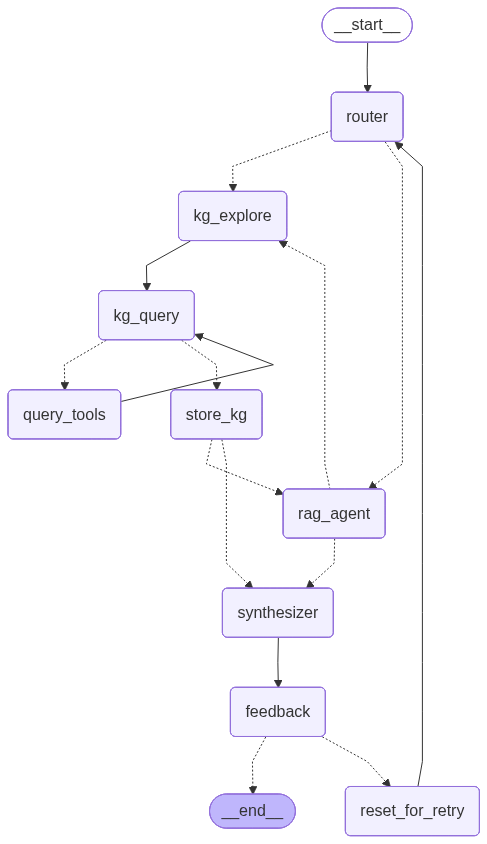

In [9]:

from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

b = StateGraph(AgentState)

b.add_node("router", router_node)
b.add_node("kg_explore", kg_explore_node)
b.add_node("kg_query", kg_query_node)
b.add_node("query_tools", ToolNode(query_tools))
b.add_node("store_kg", store_kg_result)
b.add_node("rag_agent", rag_agent_node)
b.add_node("synthesizer", synthesizer_node)
b.add_node("feedback", feedback_node)
b.add_node("reset_for_retry", reset_for_retry)

b.add_edge(START, "router")
b.add_conditional_edges("router", route_after_router, {"kg_explore": "kg_explore", "rag_agent": "rag_agent"})

# Deterministic KG exploration always proceeds directly to the SPARQL query agent.
b.add_edge("kg_explore", "kg_query")

# SPARQL query generation remains agentic and may execute/refine SPARQL queries.
b.add_conditional_edges("kg_query", kg_query_condition, {"query_tools": "query_tools", "store_kg": "store_kg"})
b.add_edge("query_tools", "kg_query")
b.add_conditional_edges("store_kg", route_after_kg, {"rag_agent": "rag_agent", "synthesizer": "synthesizer"})

# RAG retrieval is deterministic and executes once per pass.
b.add_conditional_edges("rag_agent", route_after_rag, {"kg_explore": "kg_explore", "synthesizer": "synthesizer"})

b.add_edge("synthesizer", "feedback")
b.add_conditional_edges("feedback", route_after_feedback, {"reset_for_retry": "reset_for_retry", "__end__": END})
b.add_edge("reset_for_retry", "router")

react_graph_memory = b.compile(checkpointer=MemorySaver())
display(Image(react_graph_memory.get_graph(xray=True).draw_mermaid_png()))


## 9. Run

In [10]:

from langchain_core.messages import HumanMessage, ToolMessage

config = {"configurable": {"thread_id": "borrajas_002"}}
question = "List all the climate events occurred in China in 2014."

initial_state = {
    "messages": [HumanMessage(content=question)],
    "order": "kg_first",
    "kg_explored": False,
    "kg_done": False,
    "rag_done": False,
    "explore_summary": "",
    "sparql_result": "",
    "rag_result": "",
    "final_answer": "",
    "feedback_result": "negative",
    "feedback_count": 0,
    "query_call_count": 0,
}

result = react_graph_memory.invoke(initial_state, config)

print("\n=== FINAL ANSWER ===")
print(result["final_answer"])
print(f"\nFeedback iterations : {result['feedback_count']}")
print(f"Final verdict       : {result['feedback_result']}")

source_status = {
    "KG explored": bool(result.get("kg_explored")),
    "KG queried": bool(result.get("kg_done")),
    "RAG searched": bool(result.get("rag_done")),
}
print("\nSource coverage:")
for label, value in source_status.items():
    print(f"  {label}: {value}")

tool_msgs = [m for m in result["messages"] if isinstance(m, ToolMessage)]
print(f"\nSPARQL tool messages ({len(tool_msgs)} total):")
for i, m in enumerate(tool_msgs, 1):
    print(f"  {i}. {m.name}")


[Router] kg_first
[Explore] deterministic KG profiling complete: **EXPLORATION SUMMARY – “Climate events in China (2014)”**

---

### 1️⃣ Relevant Classes & Predicat...
[KG Query] done in 2 LLM turn(s): The KG returned several climate‑event instances whose `gn:locatedIn` country has the name “China” an...
[RAG] Loading existing Chroma DB...


/var/folders/m5/_gg_c8dx3_7cl1gy0wn_kn6r0000gn/T/ipykernel_53054/2567190060.py:80: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  return Chroma(


[RAG] deterministic retrieval complete: The retrieval step did not return any documents containing information about climate events in China...
[Synthesizer] attempt 1
[Feedback #1] NEGATIVE - The answer is incomplete because it does not list all the climate events from the KG (it omits the additional events mentioned) and thus fails to fully satisfy the request to list every event.
[Feedback] retrying
[Reset] retry #1...
[Router] kg_first
[Explore] deterministic KG profiling complete: **EXPLORATION SUMMARY – “List all the climate events occurred in China in 2014”**

| **What we know ...
[KG Query] done in 1 LLM turn(s): The KG contains climate‑event instances located in China whose start‑ or end‑date falls in 2014. The...
[RAG] deterministic retrieval complete: **Retrieval result:** The corpus did not return any relevant documents for the query. Consequently, ...
[Synthesizer] attempt 2
[Feedback #2] NEGATIVE - The answer does not provide a complete list of all 2014 climate events in 

In [11]:
print("\n=== CONVERSATION ===")
for m in result["messages"]:
    m.pretty_print()


=== CONVERSATION ===
================================ Human Message =================================

List all the climate events occurred in China in 2014.
================================ Human Message =================================

EXPLORATION SUMMARY:
**EXPLORATION SUMMARY – “Climate events in China (2014)”**

---

### 1️⃣ Relevant Classes & Predicates (as profiled)

| Class (URI)                              | Key predicates that appear on instances (profiled) |
|------------------------------------------|---------------------------------------------------|
| **irdr:ClimateEvent**                    | `rdf:type` (→ irdr:ClimateEvent) <br> `rdfs:label` <br> `gn:locatedIn` (→ country URI) <br> `soteria:startDate` <br> `soteria:endDate` <br> `sorelsc:hasImpact` <br> `irdr:hasDisasterType` <br> `irdr:hasDisasterSubtype` <br> `irdr:hasDisasterSubgroup` <br> `irdr:isInProvince` |
| **(Country – gn:GeographicalFeature)**  | `gn:name` (country’s literal name) – *present in the globa

In [12]:

from langchain_core.messages import HumanMessage, ToolMessage

config = {"configurable": {"thread_id": "borrajas_002"}}
question = "What are the additional events?"

initial_state = {
    "messages": [HumanMessage(content=question)],
    "order": "kg_first",
    "kg_explored": False,
    "kg_done": False,
    "rag_done": False,
    "explore_summary": "",
    "sparql_result": "",
    "rag_result": "",
    "final_answer": "",
    "feedback_result": "negative",
    "feedback_count": 0,
    "query_call_count": 0,
}

result = react_graph_memory.invoke(initial_state, config)

print("\n=== FINAL ANSWER ===")
print(result["final_answer"])
print(f"\nFeedback iterations : {result['feedback_count']}")
print(f"Final verdict       : {result['feedback_result']}")

source_status = {
    "KG explored": bool(result.get("kg_explored")),
    "KG queried": bool(result.get("kg_done")),
    "RAG searched": bool(result.get("rag_done")),
}
print("\nSource coverage:")
for label, value in source_status.items():
    print(f"  {label}: {value}")

tool_msgs = [m for m in result["messages"] if isinstance(m, ToolMessage)]
print(f"\nSPARQL tool messages ({len(tool_msgs)} total):")
for i, m in enumerate(tool_msgs, 1):
    print(f"  {i}. {m.name}")


[Router] kg_first
[Explore] deterministic KG profiling complete: **EXPLORATION SUMMARY – “List all the climate events that occurred in China in 2014”**

| **What the...
[KG Query] done in 2 LLM turn(s): The KG contains many climate‑event instances linked to China with start dates in 2014. Examples (eve...
[RAG] deterministic retrieval complete: The retrieval did not return any documents containing information about climate events in China for ...
[Synthesizer] attempt 1
[Feedback #1] NEGATIVE - The response does not provide a complete list of all 2014 climate events in China and highlights data inconsistencies without resolving them, leaving the answer incomplete and not fully answering the user’s request.
[Feedback] retrying
[Reset] retry #1...
[Router] kg_first
[Explore] deterministic KG profiling complete: **EXPLORATION SUMMARY – “Climate events in China (2014)”**

---

### 1. Relevant Classes & Predicate...
[KG Query] done in 1 LLM turn(s): The knowledge graph contains many climate

In [13]:
print("\n=== CONVERSATION ===")
for m in result["messages"]:
    m.pretty_print()


=== CONVERSATION ===
================================ Human Message =================================

List all the climate events occurred in China in 2014.
================================ Human Message =================================

EXPLORATION SUMMARY:
**EXPLORATION SUMMARY – “Climate events in China (2014)”**

---

### 1️⃣ Relevant Classes & Predicates (as profiled)

| Class (URI)                              | Key predicates that appear on instances (profiled) |
|------------------------------------------|---------------------------------------------------|
| **irdr:ClimateEvent**                    | `rdf:type` (→ irdr:ClimateEvent) <br> `rdfs:label` <br> `gn:locatedIn` (→ country URI) <br> `soteria:startDate` <br> `soteria:endDate` <br> `sorelsc:hasImpact` <br> `irdr:hasDisasterType` <br> `irdr:hasDisasterSubtype` <br> `irdr:hasDisasterSubgroup` <br> `irdr:isInProvince` |
| **(Country – gn:GeographicalFeature)**  | `gn:name` (country’s literal name) – *present in the globa